In [ ]:
import os
import re
import torch
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from transformers import (AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback)

In [17]:
# 1. GPU Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache()
print(f"Using device: {device} ({torch.cuda.get_device_name(0)})")

Using device: cuda (GeForce GTX 1650 Ti)


In [18]:
# 2. Data Acquisition & Cleaning
ds = load_dataset("fhai50032/Symptoms_to_disease_7k")
df = pd.DataFrame(ds['train'])

def extract_symptoms(text):
    match = re.search(r"Patient:(.*)", text)
    return match.group(1).strip().lower() if match else text.lower()

df['cleaned_symptoms'] = df['query'].apply(extract_symptoms)

In [19]:
# 3. Encoding Labels
le = LabelEncoder()
df["label"] = le.fit_transform(df["response"]) 
num_labels = len(le.classes_)
print(f"Total unique diseases identified: {num_labels}")

Total unique diseases identified: 1082


In [20]:
# 4. Standard Split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [21]:
# 5. Tokenization
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(texts):
    return tokenizer(texts, truncation=True, padding=False, max_length=128)

train_encodings = tokenize_function(train_df["cleaned_symptoms"].tolist())
test_encodings = tokenize_function(test_df["cleaned_symptoms"].tolist())

class HealthcareDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = HealthcareDataset(train_encodings, train_df["label"].tolist())
test_dataset = HealthcareDataset(test_encodings, test_df["label"].tolist())

In [22]:
# 6. Model Initialization
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=num_labels
).to(device)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# 7. Training Arguments
# NOTE: Changed output_dir to v2 to avoid class mismatch errors from your previous project
output_dir = "./results_v2" 
training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=5, 
    per_device_train_batch_size=8,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=4,
    learning_rate=3e-5,
    fp16=True, 
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=None, # Keeps every epoch
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    # callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

In [79]:
# 8. Smart Train/Resume Logic
RUN_TRAINING = True 

if RUN_TRAINING:
    resume_checkpoint = None
    # Only resume if the directory exists AND we are sure it's the same class count
    if os.path.exists(output_dir) and len(os.listdir(output_dir)) > 0:
        print("\n--- Found existing checkpoints. Resuming... ---")
        resume_checkpoint = True 
    else:
        print("\n--- Starting Fresh Training (No compatible checkpoints found) ---")

    try:
        trainer.train(resume_from_checkpoint=resume_checkpoint)
        trainer.save_model("./final_healthcare_model")
    except RuntimeError as e:
        print(f"\n[Error] Could not resume: {e}")
        print("Starting fresh training instead...")
        trainer.train() # Fallback to fresh train if resume fails
        trainer.save_model("./final_healthcare_model")
else:
    model = AutoModelForSequenceClassification.from_pretrained("./final_healthcare_model").to(device)


# --- ADD THIS AFTER trainer.train() ---

# Extract history into a table format
history_data = trainer.state.log_history

# Filter and clean the logs to show only epoch-end results
records = []
for entry in history_data:
    if "eval_loss" in entry:  # This usually marks the end of an epoch
        records.append({
            "Epoch": entry.get("epoch"),
            "Training Loss": entry.get("loss", "N/A"), # May be N/A if logging_steps > epoch_steps
            "Validation Loss": entry.get("eval_loss"),
            "Accuracy": entry.get("eval_accuracy")
        })

# Create and display the table
history_df = pd.DataFrame(records)
print("\n--- FULL TRAINING HISTORY TABLE ---")
print(history_df.to_string(index=False))


--- Found existing checkpoints. Resuming... ---


There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Epoch,Training Loss,Validation Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- FULL TRAINING HISTORY TABLE ---
 Epoch Training Loss  Validation Loss  Accuracy
   1.0           N/A         2.642027  0.781405
   2.0           N/A         1.281987  0.821150
   3.0           N/A         1.173904  0.842441
   4.0           N/A         1.154118  0.846700
   5.0           N/A         1.193759  0.853087
   6.0           N/A         1.221093  0.853087
   7.0           N/A         1.257146  0.852378
   8.0           N/A         1.281490  0.853087
   9.0           N/A         1.282550  0.852378
  10.0           N/A         1.295595  0.852378
  11.0           N/A         1.345965  0.852378
  12.0           N/A         1.372807  0.851668
  13.0           N/A         1.424411  0.850958
  14.0           N/A         1.447377  0.850958
  15.0           N/A         1.474398  0.852378
  16.0           N/A         1.496885  0.853087
  17.0           N/A         1.520550  0.852378
  18.0           N/A         1.538768  0.852378
  19.0           N/A         1.553598  0.853087
  2

In [ ]:
# 9. Interactive User Input Loop
def interactive_prediction():
    model.eval()
    print("\n" + "="*50)
    print("DISEASE PREDICTION -")
    print("="*50)

    while True:
        user_input = input("\nEnter symptoms (or 'exit'): ")
        print(f"Received input: {user_input}")
        if user_input.lower() == 'exit': break
            
        inputs = tokenizer(user_input.lower(), return_tensors="pt", truncation=True, padding=True).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
            
        probs = torch.nn.functional.softmax(logits, dim=-1)
        top_probs, top_indices = torch.topk(probs, 3) 

        print(f"\nTop 3 Predictions:")
        for i in range(3):
            disease = le.inverse_transform([top_indices[0][i].item()])[0]
            conf = top_probs[0][i].item() * 100
            print(f"{i+1}. {disease}: {conf:.2f}%")

interactive_prediction()


DISEASE PREDICTION -
Received input: I have a high fever, sweating, and severe chills along with a headache

Top 3 Predictions:
1. You may have Malaria: 97.91%
2. You may have Typhoid: 0.40%
3. You may have Jaundice: 0.13%
Received input: My legs feel very heavy and achy, and I have a burning or throbbing sensation in my lower limbs

Top 3 Predictions:
1. You may have Varicose Veins: 70.96%
2. You may have Cervical Spondylosis: 6.94%
3. You may have Arthritis: 3.75%
Received input: I have a tightness in my chest and a strange aching sensation in my jaw and neck.

Top 3 Predictions:
1. You may have Arthritis: 19.88%
2. You may have Gastroesophageal Reflux Disease: 19.12%
3. You may have Allergy: 14.77%
Received input: I have severe chest pain and breathlessness, and I've started vomiting and sweating a lot.

Top 3 Predictions:
1. You may have Heart Attack: 53.73%
2. You may have Malaria: 10.38%
3. You may have Drug Reaction: 5.79%
Received input: I'm experiencing nausea and vomiting, a

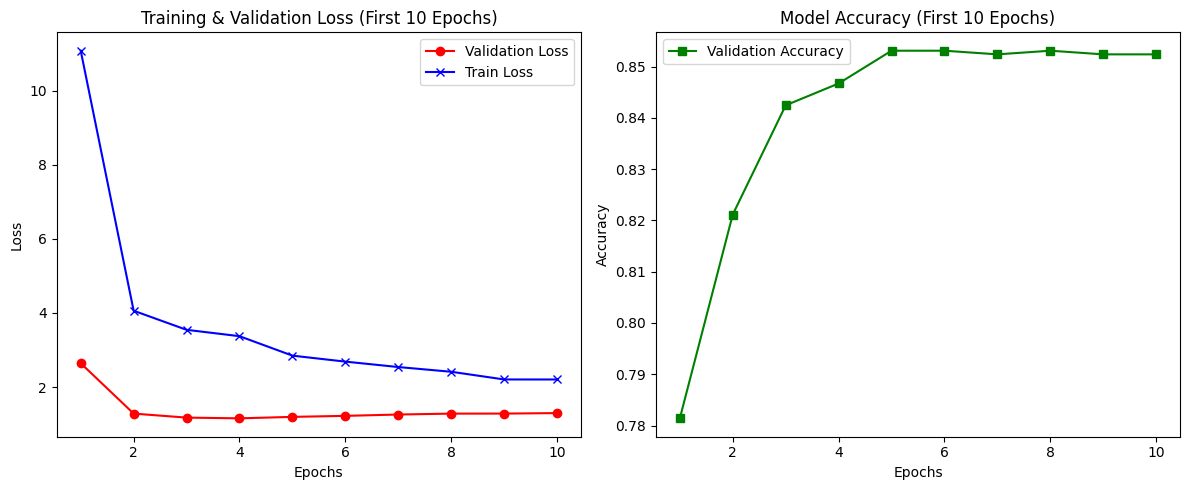

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract logs
history = trainer.state.log_history

# Separate logs
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
eval_acc = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]

# LIMIT TO FIRST 10 EPOCHS
max_epochs = 10
eval_loss = eval_loss[:max_epochs]
eval_acc = eval_acc[:max_epochs]

# train_loss may have more entries → adjust carefully
train_loss = train_loss[:max_epochs]

epochs = range(1, len(eval_loss) + 1)

# Plotting
plt.figure(figsize=(12, 5))

# Chart 1: Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs, eval_loss, label='Validation Loss', marker='o', color='red')

if len(train_loss) == len(eval_loss):
    plt.plot(epochs, train_loss, label='Train Loss', marker='x', color='blue')

plt.title('Training & Validation Loss (First 10 Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Chart 2: Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epochs, eval_acc, label='Validation Accuracy', marker='s', color='green')

plt.title('Model Accuracy (First 10 Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\CHARU\AppData\Local\Temp\ipykernel_35584\1087736297.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20.values, y=top_20.index, palette='viridis')


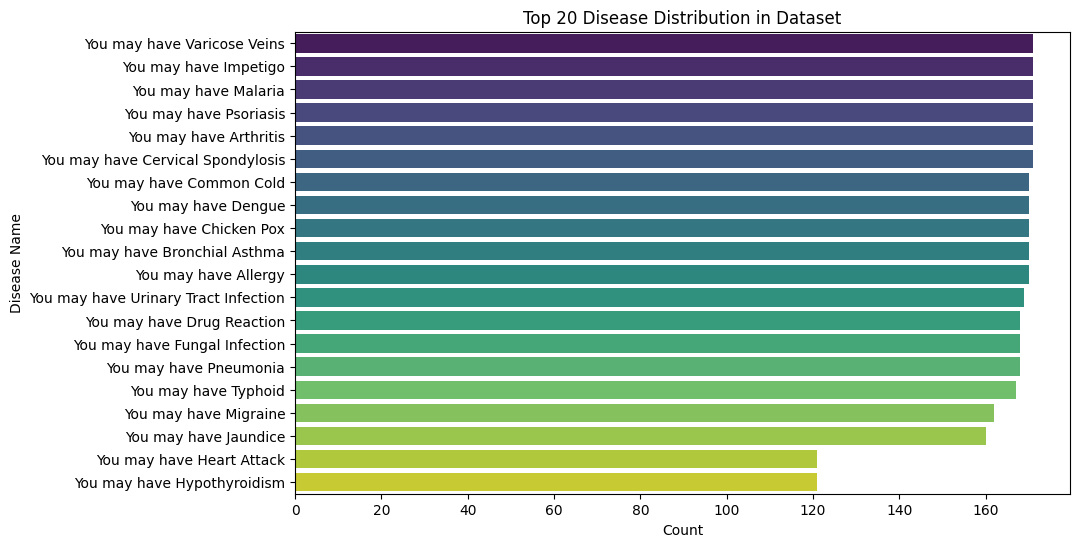

In [ ]:
# Show distribution of top 20 diseases
plt.figure(figsize=(10, 6))
top_20 = df['response'].value_counts().head(20)
sns.barplot(x=top_20.values, y=top_20.index, palette='viridis')
plt.title('Top 20 Disease Distribution in Dataset')
plt.xlabel('Count')
plt.ylabel('Disease Name')
plt.show()

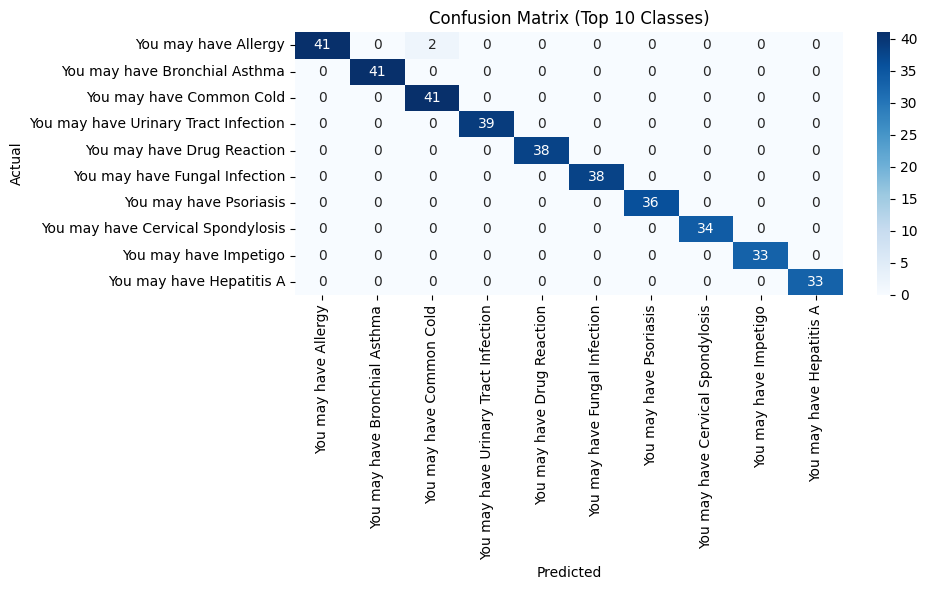

In [92]:
from collections import Counter
# Get top 10 most frequent classes in test set
top_10_classes = [cls for cls, _ in Counter(y_true).most_common(10)]

# Filter only top 10 class samples
filtered_indices = [i for i, label in enumerate(y_true) if label in top_10_classes]

y_true_top = [y_true[i] for i in filtered_indices]
y_pred_top = [y_pred[i] for i in filtered_indices]

cm = confusion_matrix(y_true_top, y_pred_top, labels=top_10_classes)

plt.figure(figsize=(10, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_[top_10_classes],
    yticklabels=le.classes_[top_10_classes]
)

plt.title("Confusion Matrix (Top 10 Classes)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [93]:
print("\n--- TOP 10 CLASSIFICATION REPORT ---")

print(classification_report(
    y_true_top,
    y_pred_top,
    labels=top_10_classes,
    target_names=le.classes_[top_10_classes]
))


--- TOP 10 CLASSIFICATION REPORT ---
                                      precision    recall  f1-score   support

                You may have Allergy       1.00      0.95      0.98        43
       You may have Bronchial Asthma       1.00      0.98      0.99        42
            You may have Common Cold       0.95      0.98      0.96        42
You may have Urinary Tract Infection       1.00      1.00      1.00        39
          You may have Drug Reaction       1.00      1.00      1.00        38
       You may have Fungal Infection       1.00      1.00      1.00        38
              You may have Psoriasis       1.00      1.00      1.00        36
   You may have Cervical Spondylosis       1.00      1.00      1.00        34
               You may have Impetigo       1.00      0.97      0.99        34
            You may have Hepatitis A       1.00      1.00      1.00        33

                           micro avg       0.99      0.99      0.99       379
                        

In [94]:
# IMPORTANT: use same labels as confusion matrix
labels = top_10_classes

# per-class accuracy
class_accuracy = cm.diagonal() / cm.sum(axis=1)

# create dataframe
acc_df = pd.DataFrame({
    "Disease": le.classes_[labels],
    "Accuracy": class_accuracy
}).sort_values(by="Accuracy", ascending=False)

print("\n--- PER-CLASS ACCURACY (TOP 10) ---")
print(acc_df)


--- PER-CLASS ACCURACY (TOP 10) ---
                                Disease  Accuracy
1         You may have Bronchial Asthma  1.000000
2              You may have Common Cold  1.000000
6                You may have Psoriasis  1.000000
3  You may have Urinary Tract Infection  1.000000
4            You may have Drug Reaction  1.000000
5         You may have Fungal Infection  1.000000
8                 You may have Impetigo  1.000000
7     You may have Cervical Spondylosis  1.000000
9              You may have Hepatitis A  1.000000
0                  You may have Allergy  0.953488
